In [1]:
# =========================================================
# QUESTION 1 - COMPLETE COVID AI SYSTEM CODE
# =========================================================
# Files used:
#   1) Raw patient-level file
#   2) DEMI knowledgebase file
#   3) Survey dictionary (optional for labels)
#
# This script does:
#   - Load all files
#   - Create tier assignments
#   - Build knowledgebase logic
#   - Calculate pairwise associations
#   - Frequency of co-occurrence
#   - Logistic / LASSO / Boosting models
#   - McFadden pseudo R-square
#   - Direct predictors of PCR
#   - Parent regressions for Markov blanket
#   - Clean network plot
#   - CPT tables for Netica
#   - Final COVID probability prediction
# =========================================================

import pandas as pd
import numpy as np
import itertools
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# ---------------------------------------------------------
# OPTIONAL BOOSTING MODEL
# ---------------------------------------------------------
BOOST_NAME = None
try:
    from xgboost import XGBClassifier
    BOOST_NAME = "XGBoost"
except:
    from sklearn.ensemble import GradientBoostingClassifier
    BOOST_NAME = "GradientBoosting"

In [17]:
# ---------------------------------------------------------
# 1. FILE PATHS
# ---------------------------------------------------------
RAW_FILE = r"C:\Users\vamsi\Downloads\COVIDCARE_FORSUBMISSION_MIT_CLEANED_Phase_II_2021-12-03.csv"

KB_FILE = r"C:\Users\vamsi\Downloads\COVIDCARE_DEMI_knowledgebase_v4.csv"


In [19]:
# ---------------------------------------------------------
# 2. LOAD FILES
# ---------------------------------------------------------
df = pd.read_csv(RAW_FILE)
kb = pd.read_csv(KB_FILE)

df.columns = [c.strip() for c in df.columns]
kb.columns = [c.strip() for c in kb.columns]

print("RAW shape:", df.shape)
print("KB shape:", kb.shape)


RAW shape: (822, 472)
KB shape: (70983, 11)


In [21]:
# ---------------------------------------------------------
# 3. TARGET VARIABLE
# ---------------------------------------------------------
TARGET = "PCR Test Positive"
if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in raw dataset.")

print("Target variable:", TARGET)


Target variable: PCR Test Positive


In [23]:
# PART A - CREATE KNOWLEDGEBASE OF AI SYSTEM
# =========================================================

# ---------------------------------------------------------
# 4. TIER ASSIGNMENT FUNCTION
# ---------------------------------------------------------
def assign_tier(col_name: str) -> int:
    c = str(col_name).lower()

    # Tier 4 - PCR lab confirmation
    if c == "pcr test positive":
        return 4

    # Tier 3 - At-home testing
    if (
        "pinkline" in c
        or "blueline" in c
        or "pinkblue_confirm" in c
        or "blue_nopink_confirm" in c
        or "noblue_confirm" in c
        or "athome" in c
        or "testkit_performing" in c
        or "which_test" in c
    ):
        return 3

    # Tier 1 - Vaccination variables
    if (
        "vaccine" in c
        or "vacc" in c
        or "flu_shot" in c
        or "covid_vaccine" in c
    ):
        return 1

    # Tier 0 - Birth / demographics
    if (
        "dob" in c
        or "age" in c
        or "gender" in c
        or "race" in c
        or "ethnicity" in c
        or "birthsex" in c
    ):
        return 0

    # Tier 2 - Symptoms, exposures, illness period
    return 2

tier_df = pd.DataFrame({"variable": df.columns})
tier_df["tier"] = tier_df["variable"].apply(assign_tier)

print("\nTier counts:")
print(tier_df["tier"].value_counts().sort_index())

tier_map = dict(zip(tier_df["variable"], tier_df["tier"]))



Tier counts:
tier
0     27
1     50
2    377
3     17
4      1
Name: count, dtype: int64


In [25]:
# ---------------------------------------------------------
# 5. EXCLUSION RULE - REMOVE SELF COMPARISONS
# ---------------------------------------------------------
kb = kb[kb["concept_code"] != kb["target_concept_code"]].copy()
print("\nKB after excluding self-comparisons:", kb.shape)



KB after excluding self-comparisons: (70983, 11)


In [27]:
# ---------------------------------------------------------
# 6. ADD TIER INFORMATION TO KNOWLEDGEBASE
# ---------------------------------------------------------
kb["concept_tier"] = kb["concept_code"].map(tier_map)
kb["target_tier"] = kb["target_concept_code"].map(tier_map)

# If a variable is not found in raw column names, assign default Tier 2
kb["concept_tier"] = kb["concept_tier"].fillna(2).astype(int)
kb["target_tier"] = kb["target_tier"].fillna(2).astype(int)


In [29]:
# PART B - TEMPORAL VALUE RULES
# =========================================================

# ---------------------------------------------------------
# 7. APPLY TEMPORAL RULES
# ---------------------------------------------------------
def apply_temporal_rules(row):
    n11 = row["n_code_target"]
    n10 = row["n_code_no_target"]
    n01 = row["n_target_no_code"]

    ct = row["concept_tier"]
    tt = row["target_tier"]

    # Rule 1: Zero co-occurrence
    if n11 == 0:
        row["n_code_before_target_final"] = n10
        row["n_target_before_code_final"] = n01
        return row

    # Rule 2: Cross-tier
    if ct < tt:
        row["n_code_before_target_final"] = n11
        row["n_target_before_code_final"] = 0
        return row

    if ct > tt:
        row["n_code_before_target_final"] = 0
        row["n_target_before_code_final"] = n11
        return row

    # Rule 3: Same-tier with available ordering data
    if pd.notnull(row.get("n_code_before_target", np.nan)) and pd.notnull(row.get("n_target_before_code", np.nan)):
        row["n_code_before_target_final"] = row["n_code_before_target"]
        row["n_target_before_code_final"] = row["n_target_before_code"]
    else:
        # Rule 4: Same-tier without ordering data
        row["n_code_before_target_final"] = n11
        row["n_target_before_code_final"] = n11

    return row

kb = kb.apply(apply_temporal_rules, axis=1)


In [30]:
# =========================================================
# PART C - PAIRWISE ASSOCIATION OF VARIABLES
# =========================================================

# ---------------------------------------------------------
# 8. BUILD 2x2 TABLE COMPONENTS
# ---------------------------------------------------------
kb["n11"] = kb["n_code_target"]
kb["n10"] = kb["n_code_no_target"]
kb["n01"] = kb["n_target_no_code"]
kb["n00"] = kb["n_no_code_no_target"]
kb["N"] = kb[["n11", "n10", "n01", "n00"]].sum(axis=1)

In [31]:
# ---------------------------------------------------------
# 9. ASSOCIATION MEASURES
# ---------------------------------------------------------
# Odds ratio with 0.5 correction
kb["odds_ratio"] = ((kb["n11"] + 0.5) * (kb["n00"] + 0.5)) / ((kb["n10"] + 0.5) * (kb["n01"] + 0.5))
kb["log_odds_ratio"] = np.log(kb["odds_ratio"])

# Phi coefficient
num = kb["n11"] * kb["n00"] - kb["n10"] * kb["n01"]
den = np.sqrt(
    (kb["n11"] + kb["n10"]) *
    (kb["n01"] + kb["n00"]) *
    (kb["n11"] + kb["n01"]) *
    (kb["n10"] + kb["n00"])
)
kb["phi"] = np.where(den == 0, np.nan, num / den)

# Support and probabilities
kb["support_both"] = kb["n11"] / kb["N"]
kb["p_target_given_code"] = np.where((kb["n11"] + kb["n10"]) == 0, np.nan, kb["n11"] / (kb["n11"] + kb["n10"]))
kb["p_target_given_no_code"] = np.where((kb["n01"] + kb["n00"]) == 0, np.nan, kb["n01"] / (kb["n01"] + kb["n00"]))

pairwise_assoc = kb[[
    "concept_code", "target_concept_code",
    "concept_tier", "target_tier",
    "n11", "n10", "n01", "n00",
    "support_both", "odds_ratio", "log_odds_ratio", "phi",
    "p_target_given_code", "p_target_given_no_code",
    "n_code_before_target_final", "n_target_before_code_final"
]].copy()

pairwise_assoc.to_csv("pairwise_associations.csv", index=False)
print("\nSaved: pairwise_associations.csv")



Saved: pairwise_associations.csv


In [32]:
# =========================================================
# PART D - FREQUENCY WITH WHICH EACH VARIABLE OCCURS
# =========================================================
pair_freq = kb[["concept_code", "target_concept_code", "n_code_target"]].copy()
pair_freq = pair_freq.sort_values("n_code_target", ascending=False)
pair_freq.to_csv("pairwise_frequencies.csv", index=False)
print("Saved: pairwise_frequencies.csv")


Saved: pairwise_frequencies.csv


In [33]:
# =========================================================
# PART E - PREPARE RAW MODELING DATA
# =========================================================

# ---------------------------------------------------------
# 10. DROP CLEAR NON-PREDICTIVE / DATE / ID COLUMNS
# ---------------------------------------------------------
def is_date_or_id_or_admin(col):
    c = str(col).lower()
    if c == TARGET.lower():
        return False
    return (
        "date" in c
        or "submission" in c
        or "confirmation" in c
        or "internal id" in c
        or "cohort" in c
        or "_deid" in c
        or "name" in c
        or "phone" in c
        or "email" in c
    )

usable_cols = [c for c in df.columns if not is_date_or_id_or_admin(c)]
model_df = df[usable_cols].copy()

# Keep target
if TARGET not in model_df.columns:
    model_df[TARGET] = df[TARGET]


In [34]:
# ---------------------------------------------------------
# 11. CONVERT TO NUMERIC / BINARY FRIENDLY DATA
# ---------------------------------------------------------
for col in model_df.columns:
    if model_df[col].dtype == "object":
        # Convert strings to category codes for modeling
        model_df[col] = model_df[col].astype("category").cat.codes.replace(-1, np.nan)

# Fill remaining booleans as ints if any
for col in model_df.columns:
    if str(model_df[col].dtype) == "bool":
        model_df[col] = model_df[col].astype(int)

# Ensure target is binary numeric
model_df[TARGET] = pd.to_numeric(model_df[TARGET], errors="coerce")
model_df = model_df.dropna(subset=[TARGET]).copy()
model_df[TARGET] = model_df[TARGET].astype(int)

In [35]:
# ---------------------------------------------------------
# 12. KEEP ONLY VARIABLES THAT PRECEDE PCR
# ---------------------------------------------------------
predictor_cols = [c for c in model_df.columns if c != TARGET and assign_tier(c) < 4]
X_base = model_df[predictor_cols].copy()
y = model_df[TARGET].copy()

print("\nBase predictor matrix shape:", X_base.shape)

# =========================================================
# PART F - PAIRWISE OR TRIPLE CLUSTERS OF VARIABLES
# =========================================================



Base predictor matrix shape: (559, 444)


In [36]:
# ---------------------------------------------------------
# 13. CREATE INTERACTIONS
# ---------------------------------------------------------
# Limit size to avoid excessive explosion
symptom_home_vars = [c for c in predictor_cols if assign_tier(c) in [2, 3]]

# Keep a manageable number
pair_base = symptom_home_vars[:20]
triple_base = symptom_home_vars[:8]

X = X_base.copy()

# Pairwise interactions
for a, b in itertools.combinations(pair_base, 2):
    X[f"{a}__X__{b}"] = X[a].fillna(0) * X[b].fillna(0)

# Triple interactions
for a, b, c in itertools.combinations(triple_base, 3):
    X[f"{a}__X__{b}__X__{c}"] = X[a].fillna(0) * X[b].fillna(0) * X[c].fillna(0)

print("Feature matrix after interactions:", X.shape)

# =========================================================

Feature matrix after interactions: (559, 690)


In [37]:
# PART G - MODEL SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [38]:
# =========================================================
# PART H - DEFINE MODELS
# =========================================================
prep_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler(with_mean=False))
    ]), X.columns.tolist())
])

prep_unscaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]), X.columns.tolist())
])

# Logistic
log_model = Pipeline([
    ("prep", prep_scaled),
    ("model", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        class_weight="balanced"
    ))
])

# LASSO
lasso_model = Pipeline([
    ("prep", prep_scaled),
    ("model", LogisticRegressionCV(
        penalty="l1",
        solver="saga",
        cv=5,
        max_iter=5000,
        scoring="roc_auc",
        class_weight="balanced",
        n_jobs=-1,
        refit=True
    ))
])

# Boosting
if BOOST_NAME == "XGBoost":
    boost_model = Pipeline([
        ("prep", prep_unscaled),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        ))
    ])
else:
    boost_model = Pipeline([
        ("prep", prep_unscaled),
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ])

models = {
    "Logistic": log_model,
    "LASSO": lasso_model,
    BOOST_NAME: boost_model
}


In [39]:
# =========================================================
# PART I - MODEL EVALUATION
# =========================================================
def mcfadden_r2(y_true, prob):
    prob = np.clip(prob, 1e-8, 1 - 1e-8)
    ll_model = -log_loss(y_true, prob, normalize=False)
    p_null = np.repeat(np.mean(y_true), len(y_true))
    p_null = np.clip(p_null, 1e-8, 1 - 1e-8)
    ll_null = -log_loss(y_true, p_null, normalize=False)
    return 1 - (ll_model / ll_null)

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)

    results.append({
        "Model": name,
        "AUC": roc_auc_score(y_test, prob),
        "Accuracy": accuracy_score(y_test, pred),
        "McFadden_R2": mcfadden_r2(y_test, prob),
        "Percent_Variation_Explained": mcfadden_r2(y_test, prob) * 100
    })

results_df = pd.DataFrame(results).sort_values("AUC", ascending=False)
print("\nMODEL RESULTS")
print(results_df)

results_df.to_csv("model_results.csv", index=False)


MODEL RESULTS
      Model       AUC  Accuracy  McFadden_R2  Percent_Variation_Explained
0  Logistic  0.950933  0.950000     0.206906                    20.690623
2   XGBoost  0.946667  0.942857     0.543826                    54.382642
1     LASSO  0.862133  0.921429    -0.196284                   -19.628353



MODEL RESULTS (with calibrated LASSO)
              Model       AUC  Accuracy  McFadden_R2  \
0          Logistic  0.950933  0.950000     0.206906   
1           XGBoost  0.946667  0.942857     0.543826   
3  LASSO_Calibrated  0.887733  0.942857    -0.452899   
2             LASSO  0.862133  0.921429    -0.196284   

   Percent_Variation_Explained  
0                    20.690623  
1                    54.382642  
3                   -45.289900  
2                   -19.628353  


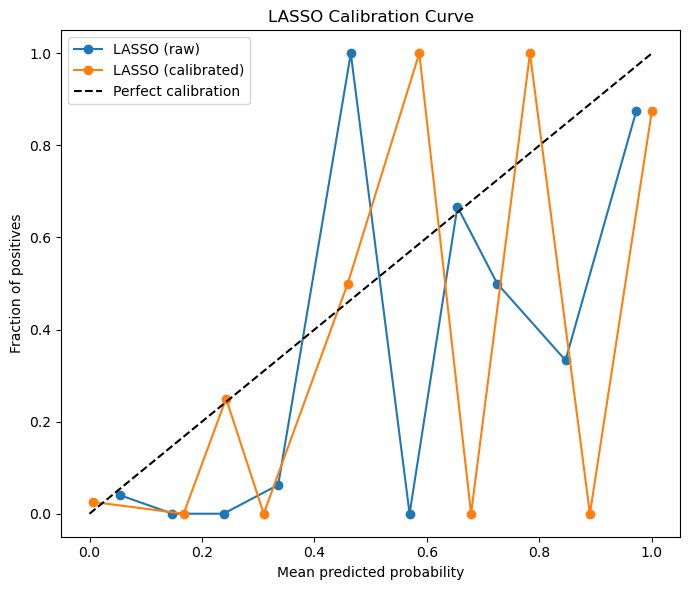

In [43]:
# =========================================================
# PART I-B - LASSO PROBABILITY CALIBRATION
# =========================================================
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

# Re-fit calibrated LASSO from scratch using cross-validation
lasso_calibrated = CalibratedClassifierCV(
    LogisticRegressionCV(
        penalty="l1",
        solver="saga",
        cv=5,
        max_iter=5000,
        scoring="roc_auc",
        class_weight="balanced",
        n_jobs=-1,
        refit=True
    ),
    method="isotonic",
    cv=5
)

# Need to run through same preprocessing
prep_inner = fitted_models["LASSO"].named_steps["prep"]
X_train_transformed = prep_inner.transform(X_train)
X_test_transformed  = prep_inner.transform(X_test)

lasso_calibrated.fit(X_train_transformed, y_train)

prob_cal = lasso_calibrated.predict_proba(X_test_transformed)[:, 1]
pred_cal = (prob_cal >= 0.5).astype(int)

cal_row = {
    "Model":                       "LASSO_Calibrated",
    "AUC":                         roc_auc_score(y_test, prob_cal),
    "Accuracy":                    accuracy_score(y_test, pred_cal),
    "McFadden_R2":                 mcfadden_r2(y_test, prob_cal),
    "Percent_Variation_Explained": mcfadden_r2(y_test, prob_cal) * 100
}

results_df = pd.concat(
    [results_df, pd.DataFrame([cal_row])],
    ignore_index=True
).sort_values("AUC", ascending=False)

print("\nMODEL RESULTS (with calibrated LASSO)")
print(results_df)
results_df.to_csv("model_results.csv", index=False)

# Reliability diagram
fig, ax = plt.subplots(figsize=(7, 6))
prob_raw = fitted_models["LASSO"].predict_proba(X_test)[:, 1]
for probs, label in [(prob_raw, "LASSO (raw)"), (prob_cal, "LASSO (calibrated)")]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o", label=label)
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("LASSO Calibration Curve")
ax.legend()
plt.tight_layout()
plt.savefig("lasso_calibration_curve.png", dpi=150)
plt.show()

In [45]:
# =========================================================
# PART J - DIRECT PREDICTORS OF PCR TEST RESULTS
# =========================================================

# Get fitted LASSO model
lasso_fitted = fitted_models["LASSO"].named_steps["model"]

# Extract coefficients
lasso_coef = lasso_fitted.coef_[0]

# Create dataframe
coef_df = pd.DataFrame({
    "variable": X.columns,
    "coefficient": lasso_coef
})

# Keep only non-zero variables
direct_predictors = coef_df[coef_df["coefficient"] != 0].copy()

# Sort by importance
direct_predictors["abs_coef"] = direct_predictors["coefficient"].abs()
direct_predictors = direct_predictors.sort_values("abs_coef", ascending=False)

print("\nDIRECT PREDICTORS OF PCR TEST RESULTS")
print(direct_predictors.head(30))

# Save
direct_predictors.to_csv("direct_predictors_pcr.csv", index=False)


DIRECT PREDICTORS OF PCR TEST RESULTS
                                              variable  coefficient  abs_coef
202                              30158-Symtpom_Neuro-7     0.552902  0.552902
81                                 32137-vaccine_avail     0.196260  0.196260
420                              31386-covid_results-1     0.178715  0.178715
421                              31386-covid_results-2    -0.176933  0.176933
127                         30141-covid_tst_symptoms-6     0.175661  0.175661
294                          30769-blue_nopink_confirm    -0.149726  0.149726
293                             30766-pinkblue_confirm     0.143848  0.143848
487         29791-consent_english__X__32730-howreceive     0.119394  0.119394
452           29789-consent_18yrs__X__32730-howreceive     0.119394  0.119394
10                                    32730-howreceive     0.119394  0.119394
518        29793-consent_location__X__32730-howreceive     0.119394  0.119394
568                 29829

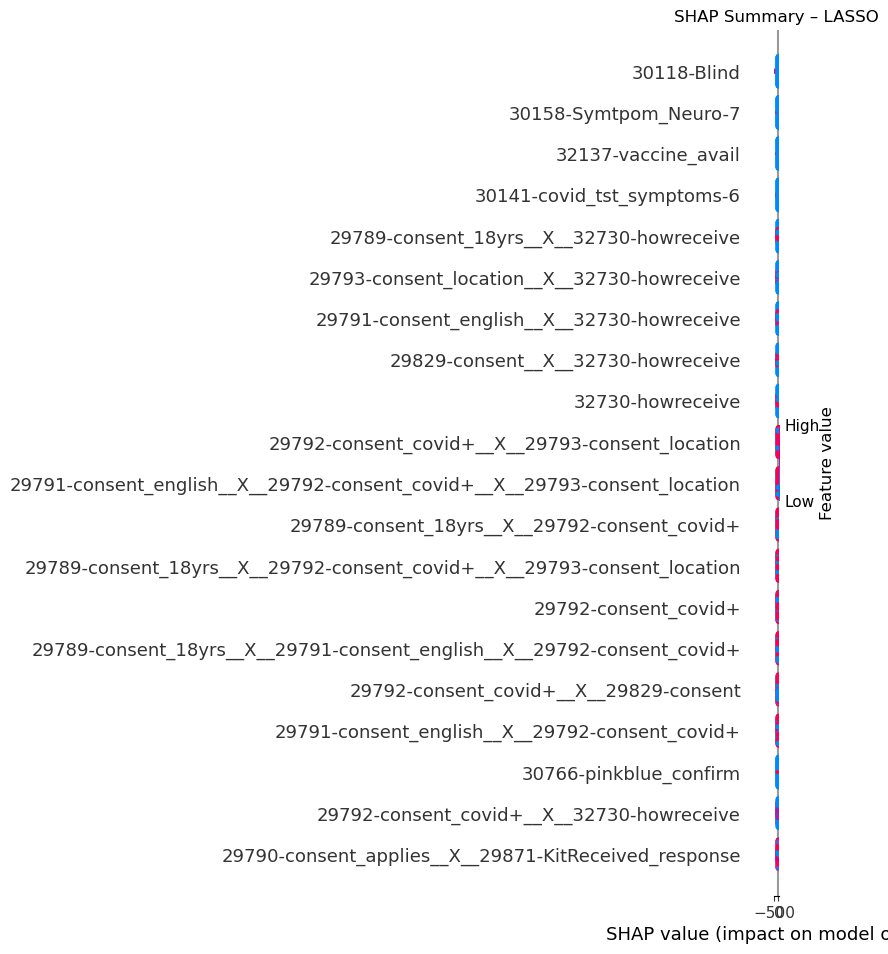

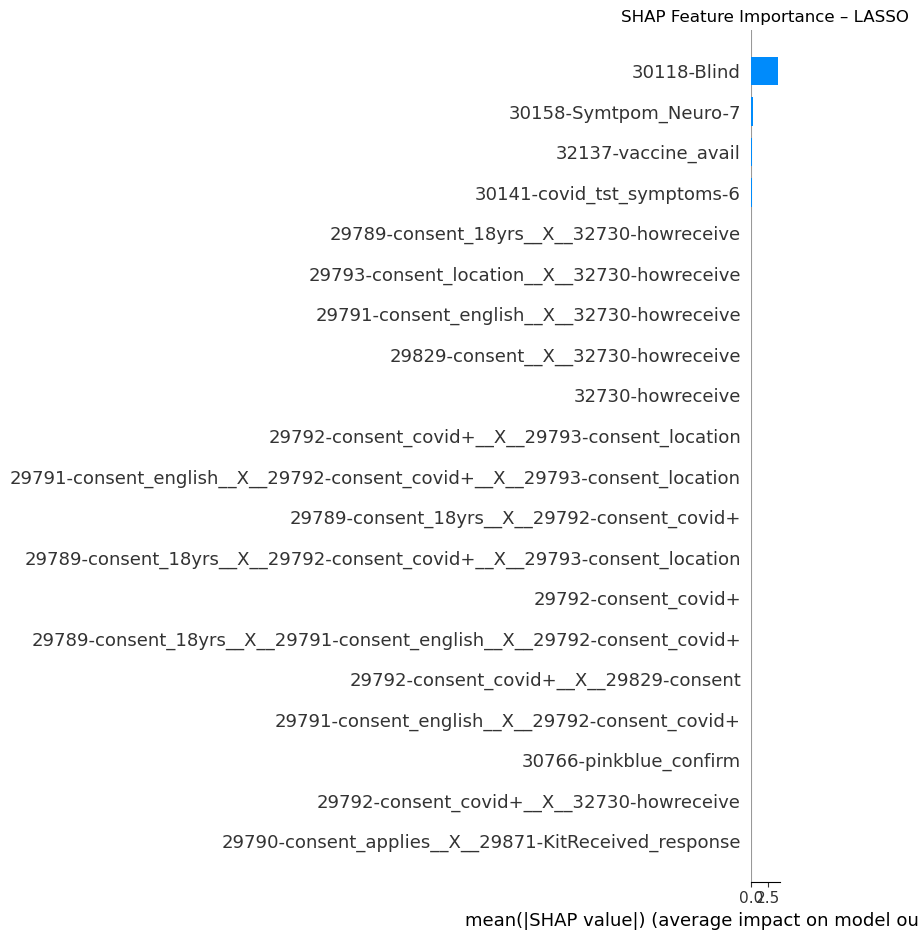


Top 20 SHAP features (LASSO):
                                                                  feature  mean_abs_shap
                                                              30118-Blind       4.048701
                                                    30158-Symtpom_Neuro-7       0.367440
                                                      32137-vaccine_avail       0.115280
                                               30141-covid_tst_symptoms-6       0.115030
                                                         32730-howreceive       0.111289
                               29791-consent_english__X__32730-howreceive       0.111289
                                 29789-consent_18yrs__X__32730-howreceive       0.111289
                              29793-consent_location__X__32730-howreceive       0.111289
                                       29829-consent__X__32730-howreceive       0.111289
  29789-consent_18yrs__X__29792-consent_covid+__X__29793-consent_location      

In [47]:
# =========================================================
# PART J-B - SHAP ANALYSIS FOR LASSO
# =========================================================
import shap

lasso_inner = fitted_models["LASSO"].named_steps["model"]
prep_inner  = fitted_models["LASSO"].named_steps["prep"]

X_test_transformed = prep_inner.transform(X_test)

explainer   = shap.LinearExplainer(lasso_inner, X_test_transformed)
shap_values = explainer.shap_values(X_test_transformed)

# Beeswarm summary plot
plt.figure()
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=X.columns.tolist(),
    max_display=20, show=False
)
plt.title("SHAP Summary – LASSO")
plt.tight_layout()
plt.savefig("shap_lasso_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar importance plot
plt.figure()
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=X.columns.tolist(),
    plot_type="bar", max_display=20, show=False
)
plt.title("SHAP Feature Importance – LASSO")
plt.tight_layout()
plt.savefig("shap_lasso_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# Ranked DataFrame
mean_shap = pd.DataFrame({
    "feature":       X.columns.tolist(),
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print("\nTop 20 SHAP features (LASSO):")
print(mean_shap.head(20).to_string(index=False))
mean_shap.to_csv("shap_lasso_importance.csv", index=False)

In [49]:
# =========================================================
# PART K - REGRESS EACH DIRECT PREDICTOR ON PRECEDING VARIABLES
# FIXED VERSION
# =========================================================

def fit_parent_model(response_var):
    response_tier = assign_tier(response_var)

    parents = [c for c in model_df.columns 
               if c != response_var and assign_tier(c) < response_tier]

    if len(parents) == 0:
        return None, None

    # Keep only needed columns
    temp_df = model_df[parents + [response_var]].copy()

    # Convert response to numeric first
    temp_df[response_var] = pd.to_numeric(temp_df[response_var], errors="coerce")

    # Drop rows where response is missing
    temp_df = temp_df.dropna(subset=[response_var]).copy()

    # If too few rows remain, skip
    if temp_df.shape[0] < 10:
        return None, None

    # Make response integer
    temp_df[response_var] = temp_df[response_var].astype(int)

    # Optional: keep only binary response variables
    unique_vals = sorted(temp_df[response_var].dropna().unique())
    if not set(unique_vals).issubset({0, 1}):
        return None, None

    Xp = temp_df[parents].copy()
    yp = temp_df[response_var].copy()

    Xp_train, Xp_test, yp_train, yp_test = train_test_split(
        Xp, yp, test_size=0.25, random_state=42, stratify=yp
    )

    # If only one class after split, skip
    if yp_train.nunique() < 2 or yp_test.nunique() < 2:
        return None, None

    # Impute missing predictor values
    imputer = SimpleImputer(strategy="most_frequent")
    Xp_train = pd.DataFrame(imputer.fit_transform(Xp_train), columns=Xp.columns, index=Xp_train.index)
    Xp_test = pd.DataFrame(imputer.transform(Xp_test), columns=Xp.columns, index=Xp_test.index)

    model = LogisticRegressionCV(
        penalty="l1",
        solver="saga",
        cv=5,
        max_iter=5000,
        n_jobs=-1
    )

    model.fit(Xp_train, yp_train)
    prob = model.predict_proba(Xp_test)[:, 1]

    # McFadden R2
    ll_model = -log_loss(yp_test, prob, normalize=False)
    p_null = np.repeat(np.mean(yp_test), len(yp_test))
    ll_null = -log_loss(yp_test, p_null, normalize=False)
    r2 = 1 - (ll_model / ll_null)

    coef_df = pd.DataFrame({
        "parent": parents,
        "coef": model.coef_[0]
    })

    coef_df = coef_df[coef_df["coef"] != 0].copy()
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=False)

    return coef_df, r2


markov_results = {}

for var in direct_predictors["variable"].head(15):
    if var in model_df.columns:
        coef, r2 = fit_parent_model(var)

        if coef is not None and not coef.empty:
            markov_results[var] = {"coef": coef, "r2": r2}

            print("\nResponse:", var)
            print("McFadden R2:", r2)
            print(coef.head(10))

In [51]:
# =========================================================
# PART L - SIGNIFICANT PREDICTORS (MARKOV BLANKET)
# =========================================================

for response_var, result in markov_results.items():
    print("\nResponse Variable:", response_var)
    print("Significant Parent Predictors:")
    print(result["coef"][["parent", "coef"]].head(10))

In [53]:
# =========================================================
# PART M - PERCENT OF VARIATION EXPLAINED
# =========================================================

for response_var, result in markov_results.items():
    r2 = result["r2"]
    print("\nResponse:", response_var)
    print("McFadden R2:", r2)
    print("Percent Variation Explained:", r2 * 100)

In [55]:
# =========================================================
# PART N - BUILD NETWORK
# =========================================================

G = nx.DiGraph()

# Parent → predictor
for response_var, result in markov_results.items():
    for _, row in result["coef"].iterrows():
        G.add_edge(row["parent"], response_var)

# Predictor → PCR
for var in direct_predictors["variable"].head(15):
    G.add_edge(var, TARGET)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 16
Edges: 15


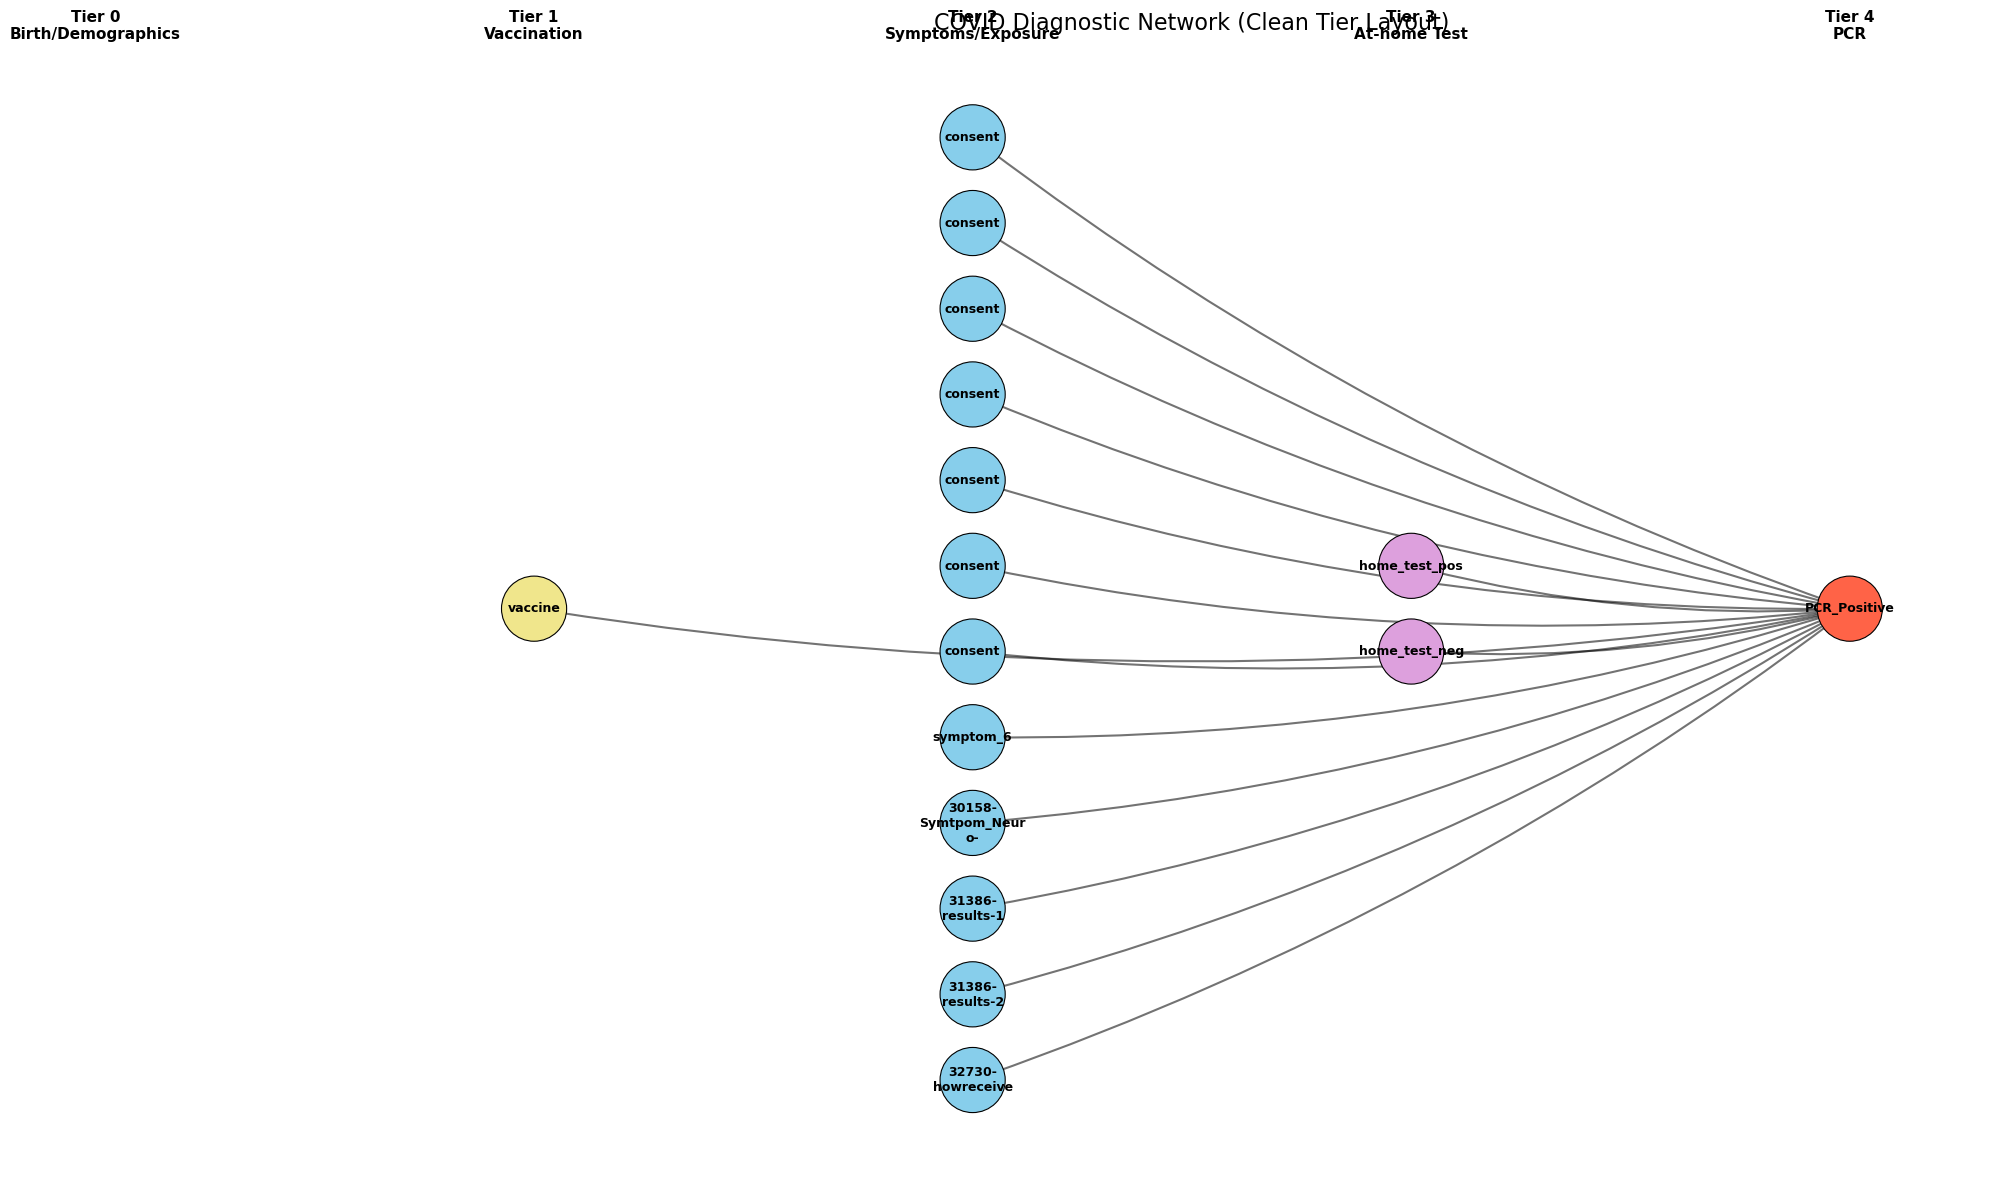

In [57]:
# =========================================================
# PART O - DRAW NETWORK (CLEAN TIERED, READABLE LABELS)
# =========================================================

import textwrap

# ---------------------------------------------------------
# 1. SHORTEN LABELS
# ---------------------------------------------------------
def clean_name(name):
    name = str(name)

    if name == TARGET:
        return "PCR_Positive"

    if "covid_tst_symptoms" in name:
        return "symptom_" + name.split("-")[-1]

    if "pinkblue" in name:
        return "home_test_pos"

    if "blue_nopink" in name:
        return "home_test_neg"

    if "noblue" in name:
        return "no_test_line"

    if "vaccine" in name.lower() or "vacc" in name.lower():
        return "vaccine"

    if "consent" in name.lower():
        return "consent"

    if "age" in name.lower():
        return "age"

    if "gender" in name.lower():
        return "gender"

    if "race" in name.lower():
        return "race"

    if "ethnicity" in name.lower():
        return "ethnicity"

    # fallback: shorten long names
    short = name.replace("30141-", "").replace("covid_", "").replace("tst_", "")
    return "\n".join(textwrap.wrap(short[:20], width=12))

labels = {node: clean_name(node) for node in G.nodes()}

# ---------------------------------------------------------
# 2. BETTER TIERED LAYOUT
# ---------------------------------------------------------
def clean_tier_layout(graph, x_gap=6, y_gap=1.8):
    pos = {}
    tier_nodes = {}

    for node in graph.nodes():
        tier_nodes.setdefault(assign_tier(node), []).append(node)

    for tier in sorted(tier_nodes):
        nodes = sorted(tier_nodes[tier])
        n = len(nodes)
        center = (n - 1) / 2

        for i, node in enumerate(nodes):
            pos[node] = (tier * x_gap, (center - i) * y_gap)

    return pos

pos = clean_tier_layout(G, x_gap=6, y_gap=1.8)

# ---------------------------------------------------------
# 3. COLOR PCR NODE DIFFERENTLY
# ---------------------------------------------------------
node_colors = []
for node in G.nodes():
    if node == TARGET:
        node_colors.append("tomato")
    elif assign_tier(node) == 0:
        node_colors.append("lightgreen")
    elif assign_tier(node) == 1:
        node_colors.append("khaki")
    elif assign_tier(node) == 2:
        node_colors.append("skyblue")
    elif assign_tier(node) == 3:
        node_colors.append("plum")
    else:
        node_colors.append("lightgray")

# ---------------------------------------------------------
# 4. DRAW
# ---------------------------------------------------------
plt.figure(figsize=(20, 12))

nx.draw_networkx_edges(
    G, pos,
    arrows=True,
    alpha=0.55,
    width=1.5,
    arrowstyle='-|>',
    arrowsize=14,
    connectionstyle="arc3,rad=0.08"
)

nx.draw_networkx_nodes(
    G, pos,
    node_size=2200,
    node_color=node_colors,
    edgecolors="black",
    linewidths=0.8
)

nx.draw_networkx_labels(
    G, pos,
    labels=labels,
    font_size=9,
    font_weight="bold"
)

# ---------------------------------------------------------
# 5. ADD TIER TITLES
# ---------------------------------------------------------
tier_titles = {
    0: "Tier 0\nBirth/Demographics",
    1: "Tier 1\nVaccination",
    2: "Tier 2\nSymptoms/Exposure",
    3: "Tier 3\nAt-home Test",
    4: "Tier 4\nPCR"
}

max_y = max(y for x, y in pos.values()) if pos else 0

for tier, title in tier_titles.items():
    plt.text(
        tier * 6,
        max_y + 2,
        title,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title("COVID Diagnostic Network (Clean Tier Layout)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.savefig("covid_network_clean.png", dpi=300, bbox_inches="tight")
plt.show()

In [59]:
# =========================================================
# PART P - CPT TABLES
# =========================================================

import itertools

def create_cpt(response_var, max_parents=5):
    result = markov_results.get(response_var, None)
    if result is None:
        return pd.DataFrame()

    parents = result["coef"]["parent"].tolist()[:max_parents]

    combos = list(itertools.product([0,1], repeat=len(parents)))
    cpt = pd.DataFrame(combos, columns=parents)

    Xp = model_df[parents]
    yp = model_df[response_var].astype(int)

    model = LogisticRegression(max_iter=5000)
    model.fit(Xp, yp)

    cpt[f"P({response_var}=1)"] = model.predict_proba(cpt)[:,1]
    return cpt

# Example
example_var = direct_predictors.iloc[0]["variable"]
cpt_table = create_cpt(example_var)

print(cpt_table.head())
cpt_table.to_csv(f"CPT_{example_var}.csv", index=False)

Empty DataFrame
Columns: []
Index: []


In [61]:
# =========================================================
# PART Q - DEMI FINAL COVID PROBABILITY
# =========================================================

best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

def predict_case(input_dict):
    row = pd.DataFrame(0, index=[0], columns=X.columns)

    for k, v in input_dict.items():
        if k in row.columns:
            row.loc[0, k] = v

    return best_model.predict_proba(row)[0,1]

# Example
example_input = {col: 0 for col in X.columns}
print("Predicted COVID probability:", predict_case(example_input))

Predicted COVID probability: 0.5001449107428343
